# Lab 7 - Tomás Pettit (G00419414)

**Module:** Artificial Intelligence  
**Topic:** Uninformed Search Algorithms

## Setup 
Run the cell below to import the required libraries.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from copy import deepcopy

# For cleaner notebook output
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100


## Part 1: Building a Semantic Network with NetworkX
### 1.1 What is a Semantic Network?
A __semantic network__ is a graph consisting of __nodes__ (vertices) connected by __links__ (edges). Nodes represent objects or states, and edges represent relationships between them. In AI, semantic networks are used to represent a problem's __search space__ — the set of all possible states and the transitions between them. 

A __semantic tree__ is a special case of a semantic network with no cycles. Many search spaces, however, contain cycles (e.g., you can walk from room A to room B and back again). The presence of cycles means our search algorithms must track __visited nodes__ to avoid infinite loops.

### 1.2 The Maze Graph

In [2]:
# Build the maze graph
maze = nx.Graph()

# Add all edges (undirected — each edge goes both ways)
# Edges (18): [('S', '1'), ('S', '6'), ('S', '8'), ('1', '2'), ('1', '3'), ('6', '5'), ('6', '7'), ('8', '7'), ('8', '14'), ('2', '10'), ('2',
# '11'), ('3', '12'), ('3', '4'), ('4', '13'), ('4', '5'), ('5', '9'), ('9', '7'), ('9', 'T')]
maze_edges = [
 ('S', '1'), ('S', '6'), ('S', '8'),
 ('1', '2'), ('1', '3'),
 ('6', '5'), ('6', '7'),
	('8', '7'), ('8', '14'),
	('2', '10'), ('2', '11'),
	('3', '12'), ('3', '4'),
	('4', '13'), ('4', '5'),
	('5', '9'),
	('9', '7'), ('9', 'T')
]
maze.add_edges_from(maze_edges)

print(f"Nodes ({maze.number_of_nodes()}): {sorted(maze.nodes())}")
print(f"Edges ({maze.number_of_edges()}): {list(maze.edges())}")
print(f"\nDead-end nodes (degree 1): {[n for n in maze.nodes() if maze.degree(n) == 1]}")
print(f"Cycles present: {len(nx.cycle_basis(maze)) > 0}")

Nodes (16): ['1', '10', '11', '12', '13', '14', '2', '3', '4', '5', '6', '7', '8', '9', 'S', 'T']
Edges (18): [('S', '1'), ('S', '6'), ('S', '8'), ('1', '2'), ('1', '3'), ('6', '5'), ('6', '7'), ('8', '7'), ('8', '14'), ('2', '10'), ('2', '11'), ('3', '12'), ('3', '4'), ('5', '4'), ('5', '9'), ('7', '9'), ('4', '13'), ('9', 'T')]

Dead-end nodes (degree 1): ['14', '10', '11', '12', '13', 'T']
Cycles present: True


### 1.3 Visualising the Graph

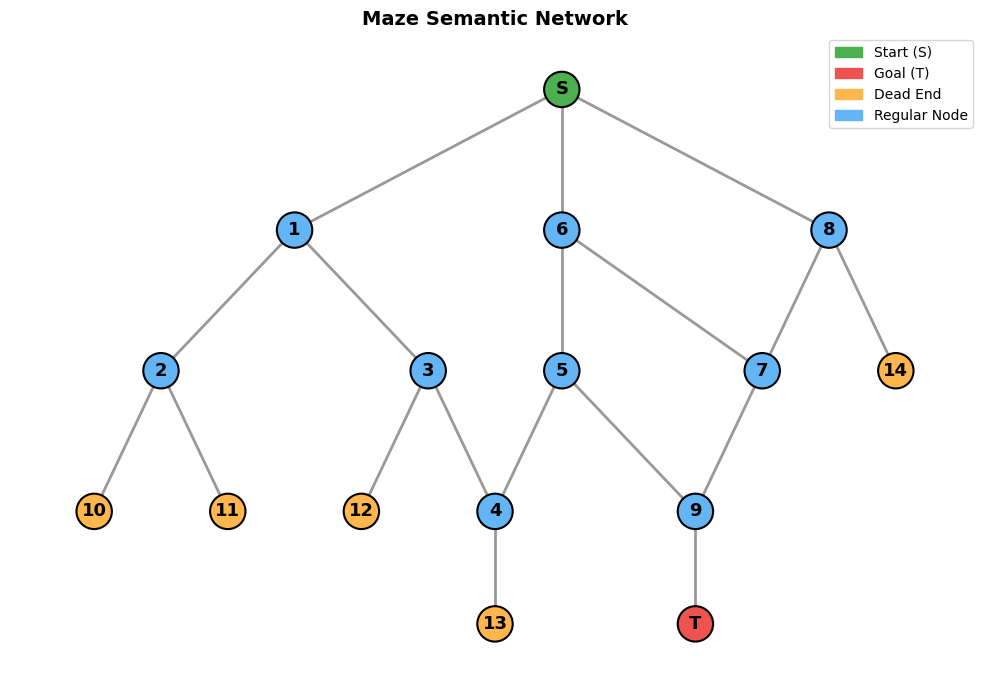

In [3]:
# Fixed positions for consistent layout
maze_pos = {
 'S': (0, 3),
 '1': (-2, 2), '6': (0, 2), '8': (2, 2),
 '2': (-3, 1), '3': (-1, 1), '5': (0, 1), '7': (1.5, 1),
 '10': (-3.5, 0), '11': (-2.5, 0), '12': (-1.5, 0), '4': (-0.5, 0),
 '14': (2.5, 1),
 '13': (-0.5, -0.8),
 '9': (1, 0),
 'T': (1, -0.8)
}

def get_node_colors(graph, start='S', goal='T'):
  """Return a list of colours for each node based on its role."""
  colors = []
  for n in graph.nodes():
      if n == start:
        colors.append('#4CAF50') # Green — start
      elif n == goal:
        colors.append('#EF5350') # Red — goal
      elif graph.degree(n) == 1:
        colors.append('#FFB74D') # Orange — dead end
      else:
        colors.append('#64B5F6') # Blue — regular
  return colors

def draw_maze(graph, pos, title='Maze Semantic Network',
 highlight_edges=None, highlight_nodes=None):
 """Draw the maze graph with optional highlighted path."""
 fig, ax = plt.subplots(figsize=(10, 7))
 
 node_colors = get_node_colors(graph)
 
 # Draw base graph
 nx.draw(graph, pos, ax=ax, with_labels=True,
 node_color=node_colors, node_size=650,
 font_size=13, font_weight='bold',
 edge_color='#999999', width=2,
 edgecolors='black', linewidths=1.5)
 
 # Highlight path if provided
 if highlight_edges:
     nx.draw_networkx_edges(graph, pos, edgelist=highlight_edges,
                            edge_color='#E91E63', width=4, ax=ax)
 if highlight_nodes:
     nx.draw_networkx_nodes(graph, pos, nodelist=highlight_nodes,
                            node_color='#E91E63', node_size=650,
                            edgecolors='black', linewidths=1.5, ax=ax)
     nx.draw_networkx_labels(graph, pos, labels={n: n for n in highlight_nodes},
                             font_size=13, font_weight='bold', ax=ax)
 
 # Legend
 legend_elements = [
 mpatches.Patch(color='#4CAF50', label='Start (S)'),
 mpatches.Patch(color='#EF5350', label='Goal (T)'),
 mpatches.Patch(color='#FFB74D', label='Dead End'),
 mpatches.Patch(color='#64B5F6', label='Regular Node'),
 ]
 if highlight_edges:
     legend_elements.append(mpatches.Patch(color='#E91E63', label='Found Path'))
 ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
 
 ax.set_title(title, fontsize=14, fontweight='bold')
 plt.tight_layout()
 plt.show()
 
# Draw the maze
draw_maze(maze, maze_pos)

### 1.4 Understanding the Graph Structure

In [4]:
# Basic graph properties
print("Graph Properties")
print("=" * 40)

print(f"Number of nodes: {maze.number_of_nodes()}")
print(f"Number of edges: {maze.number_of_edges()}")

print(f"Average degree: {sum(dict(maze.degree()).values()) / maze.number_of_nodes():.2f}")
print(f"Number of cycles: {len(nx.cycle_basis(maze))}")

print(f"\nAdjacency list:")
for node in sorted(maze.nodes()):
	neighbors = sorted(maze.neighbors(node))
	print(f" {node:>2} -> {neighbors}")

Graph Properties
Number of nodes: 16
Number of edges: 18
Average degree: 2.25
Number of cycles: 3

Adjacency list:
  1 -> ['2', '3', 'S']
 10 -> ['2']
 11 -> ['2']
 12 -> ['3']
 13 -> ['4']
 14 -> ['8']
  2 -> ['1', '10', '11']
  3 -> ['1', '12', '4']
  4 -> ['13', '3', '5']
  5 -> ['4', '6', '9']
  6 -> ['5', '7', 'S']
  7 -> ['6', '8', '9']
  8 -> ['14', '7', 'S']
  9 -> ['5', '7', 'T']
  S -> ['1', '6', '8']
  T -> ['9']


## Part 2: Breadth-First Search (BFS)
### 2.2 BFS Implementation

In [5]:
def bfs(graph, start, goal):
    """
    Breadth-First Search on a NetworkX graph.
    
    Parameters:
    graph: A NetworkX graph
    start: The starting node
    goal: The goal node
    
    Returns:
    traversal_order: List of nodes in the order they were visited
    path: List of nodes forming the path from start to goal
    (None if no path exists)
    queue_states: List of queue snapshots at each step (for tracing)
    """
    
    visited = set()
    
    # Each queue entry is (node, path_to_node)
    queue = deque([(start, [start])])
    traversal_order = []
    queue_states = []
    
    while queue:
        # Record the current state of the queue (for tracing)
        queue_states.append([node for node, _ in queue])
        
        # Dequeue from the FRONT (FIFO)
        node, path = queue.popleft()
        
        
        if node in visited:
            continue
        
        visited.add(node)
        traversal_order.append(node)
        
        # Goal test
        if node == goal:
            return traversal_order, path, queue_states
        
        # Enqueue unvisited neighbours at the BACK
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))
        
    return traversal_order, None, queue_states

### 2.3 Running BFS on the Maze

In [6]:
bfs_order, bfs_path, bfs_queues = bfs(maze, 'S', 'T')

print("BFS Traversal Order:", bfs_order)
print(f"\nPath found: {' -> '.join(bfs_path)}")
print(f"Path length: {len(bfs_path) - 1} edges")


BFS Traversal Order: ['S', '1', '6', '8', '2', '3', '5', '7', '14', '10', '11', '12', '4', '9', '13', 'T']

Path found: S -> 6 -> 5 -> 9 -> T
Path length: 4 edges


### 2.4 Tracing the BFS Queue

In [7]:
def trace_bfs(graph, start, goal):
    """Run BFS and print a detailed trace of the queue at each step."""
    visited = set()
    queue = deque([(start, [start])])
    traversal_order = []
    queue_states = []

    step = 0
    
    print(f"{'Step':>4} {'Visiting':>10} {'Queue (after expanding)':}")
    print("-" * 70)
    
    while queue:
        node, path = queue.popleft()
    
        if node in visited:
            continue
        
        visited.add(node)
        
        step += 1
        
        if node == goal:
            print(f"{step:>4} {node:>10} ** GOAL FOUND **")
            print(f"\nPath: {' -> '.join(path)}")
            print(f"Path length: {len(path) - 1} edges")
            return path
        
        # Add unvisited neighbours
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))
        
        queue_contents = [n for n, _ in queue]
        print(f"{step:>4} {node:>10} {queue_contents}")
    
    return None
bfs_result = trace_bfs(maze, 'S', 'T')

Step   Visiting Queue (after expanding)
----------------------------------------------------------------------
   1          S ['1', '6', '8']
   2          1 ['6', '8', '2', '3']
   3          6 ['8', '2', '3', '5', '7']
   4          8 ['2', '3', '5', '7', '14', '7']
   5          2 ['3', '5', '7', '14', '7', '10', '11']
   6          3 ['5', '7', '14', '7', '10', '11', '12', '4']
   7          5 ['7', '14', '7', '10', '11', '12', '4', '4', '9']
   8          7 ['14', '7', '10', '11', '12', '4', '4', '9', '9']
   9         14 ['7', '10', '11', '12', '4', '4', '9', '9']
  10         10 ['11', '12', '4', '4', '9', '9']
  11         11 ['12', '4', '4', '9', '9']
  12         12 ['4', '4', '9', '9']
  13          4 ['4', '9', '9', '13']
  14          9 ['9', '13', 'T']
  15         13 ['T']
  16          T ** GOAL FOUND **

Path: S -> 6 -> 5 -> 9 -> T
Path length: 4 edges


### 2.5 Visualising the BFS Path

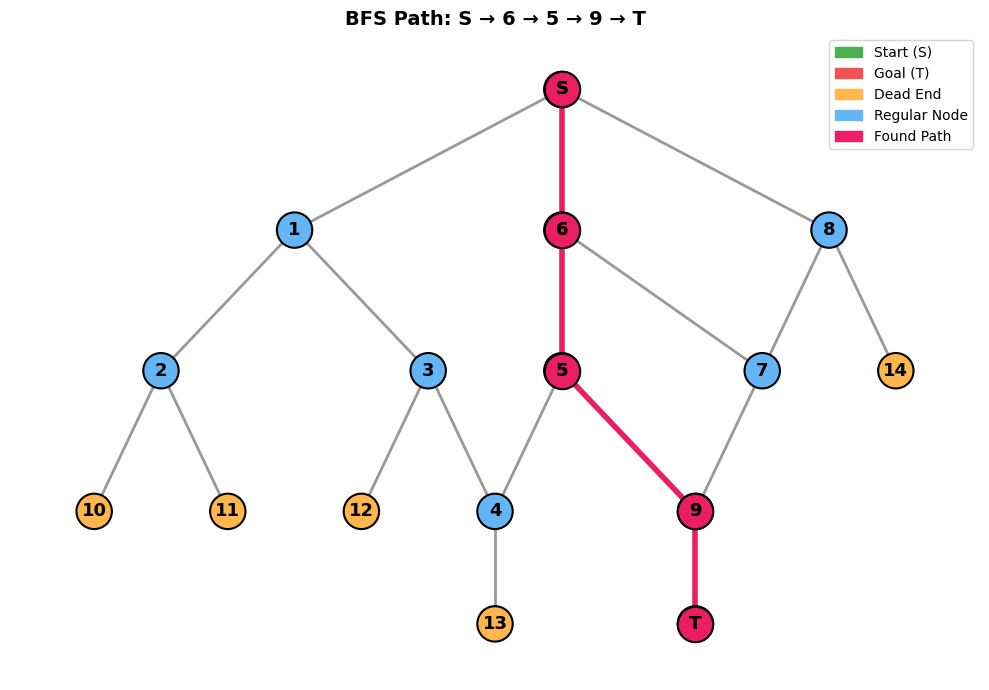

In [8]:
# Convert path to edges for highlighting
bfs_edges = list(zip(bfs_path[:-1], bfs_path[1:]))
draw_maze(maze, maze_pos, title=f'BFS Path: {" → ".join(bfs_path)}',
            highlight_edges=bfs_edges, highlight_nodes=bfs_path)

### 2.6 Verifying with NetworkX

In [9]:
# NetworkX BFS shortest path
nx_bfs_path = nx.shortest_path(maze, source='S', target='T')

print(f"Our BFS path: {bfs_path}")
print(f"NetworkX BFS path: {list(nx_bfs_path)}")
print(f"Match: {bfs_path == list(nx_bfs_path)}")

# NetworkX BFS traversal order
nx_bfs_order = list(nx.bfs_tree(maze, 'S').nodes())
print(f"\nOur BFS order: {bfs_order}")
print(f"NetworkX BFS order: {nx_bfs_order}")

Our BFS path: ['S', '6', '5', '9', 'T']
NetworkX BFS path: ['S', '6', '5', '9', 'T']
Match: True

Our BFS order: ['S', '1', '6', '8', '2', '3', '5', '7', '14', '10', '11', '12', '4', '9', '13', 'T']
NetworkX BFS order: ['S', '1', '6', '8', '2', '3', '5', '7', '14', '10', '11', '12', '4', '9', '13', 'T']


## Part 3: Depth-First Search (DFS)
### 3.2 Stack-Based DFS Implementation

In [10]:
def dfs_stack(graph, start, goal):
    """
    Depth-First Search using an explicit stack.
    
    Returns:
    traversal_order: List of nodes in the order they were visited
    path: Path from start to goal (None if not found)
    """
    visited = set()
    # LIFO stack: each entry is (node, path_to_node)
    stack = [(start, [start])]
    traversal_order = []
    
    while stack:
        # Pop from the TOP (LIFO)
        node, path = stack.pop()
        
        if node in visited:
            continue
        
        visited.add(node)
        traversal_order.append(node)
        
        # Goal test
        if node == goal:
            return traversal_order, path
        
        # Push unvisited neighbours onto the stack
        # We push in REVERSE sorted order so that the alphabetically/numerically
        # first neighbour ends up on TOP of the stack (and gets explored first)
        for neighbor in sorted(graph.neighbors(node), reverse=True):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
        
    return traversal_order, None

### 3.3 Recursive DFS Implementation

In [11]:
def dfs_recursive(graph, start, goal, visited=None, path=None, traversal_order=None):
    """
    Depth-First Search using recursion.
    
    Returns:
    traversal_order: List of nodes in the order they were visited
    path: Path from start to goal (None if not found)
    """
    if visited is None:
        visited = set()
        path = [start]
        traversal_order = []
    
    visited.add(start)
    
    traversal_order.append(start)
    
    # Goal test
    if start == goal:
        return traversal_order, path
    
    # Explore neighbours in sorted order (left-to-right)
    for neighbor in sorted(graph.neighbors(start)):
        if neighbor not in visited:
            result_order, result_path = dfs_recursive(
                graph, neighbor, goal, visited, path + [neighbor], traversal_order
            )
            if result_path is not None:
                return result_order, result_path
    
    return traversal_order, None

### 3.4 Running DFS on the Maze

In [12]:
dfs_s_order, dfs_s_path = dfs_stack(maze, 'S', 'T')
dfs_r_order, dfs_r_path = dfs_recursive(maze, 'S', 'T')

print("Stack-based DFS:")
print(f" Traversal order: {dfs_s_order}")
print(f" Path found: {' -> '.join(dfs_s_path)}")
print(f" Path length: {len(dfs_s_path) - 1} edges")

print(f"\nRecursive DFS:")
print(f" Traversal order: {dfs_r_order}")
print(f" Path found: {' -> '.join(dfs_r_path)}")
print(f" Path length: {len(dfs_r_path) - 1} edges")

Stack-based DFS:
 Traversal order: ['S', '1', '2', '10', '11', '3', '12', '4', '13', '5', '6', '7', '8', '14', '9', 'T']
 Path found: S -> 1 -> 3 -> 4 -> 5 -> 6 -> 7 -> 9 -> T
 Path length: 8 edges

Recursive DFS:
 Traversal order: ['S', '1', '2', '10', '11', '3', '12', '4', '13', '5', '6', '7', '8', '14', '9', 'T']
 Path found: S -> 1 -> 3 -> 4 -> 5 -> 6 -> 7 -> 9 -> T
 Path length: 8 edges


### 3.5 Tracing DFS (Stack-Based)

In [13]:
def trace_dfs(graph, start, goal):
    """Run stack-based DFS and print a detailed trace."""
    visited = set()
    stack = [(start, [start])]
    step = 0
    
    print(f"{'Step':>4} {'Visiting':>10} {'Stack (after expanding, top on RIGHT)':}")
    print("-" * 70)
    
    while stack:
        node, path = stack.pop()
        
        if node in visited:
            continue
        
        visited.add(node)
        
        step += 1
        
        if node == goal:
            print(f"{step:>4} {node:>10} ** GOAL FOUND **")
            print(f"\nPath: {' -> '.join(path)}")
            print(f"Path length: {len(path) - 1} edges")
            return path
        
        for neighbor in sorted(graph.neighbors(node), reverse=True):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
        
        stack_contents = [n for n, _ in stack]
        print(f"{step:>4} {node:>10} {stack_contents}")
        
    return None
dfs_result = trace_dfs(maze, 'S', 'T')

Step   Visiting Stack (after expanding, top on RIGHT)
----------------------------------------------------------------------
   1          S ['8', '6', '1']
   2          1 ['8', '6', '3', '2']
   3          2 ['8', '6', '3', '11', '10']
   4         10 ['8', '6', '3', '11']
   5         11 ['8', '6', '3']
   6          3 ['8', '6', '4', '12']
   7         12 ['8', '6', '4']
   8          4 ['8', '6', '5', '13']
   9         13 ['8', '6', '5']
  10          5 ['8', '6', '9', '6']
  11          6 ['8', '6', '9', '7']
  12          7 ['8', '6', '9', '9', '8']
  13          8 ['8', '6', '9', '9', '14']
  14         14 ['8', '6', '9', '9']
  15          9 ['8', '6', '9', 'T']
  16          T ** GOAL FOUND **

Path: S -> 1 -> 3 -> 4 -> 5 -> 6 -> 7 -> 9 -> T
Path length: 8 edges


### 3.6 Visualising the DFS Path

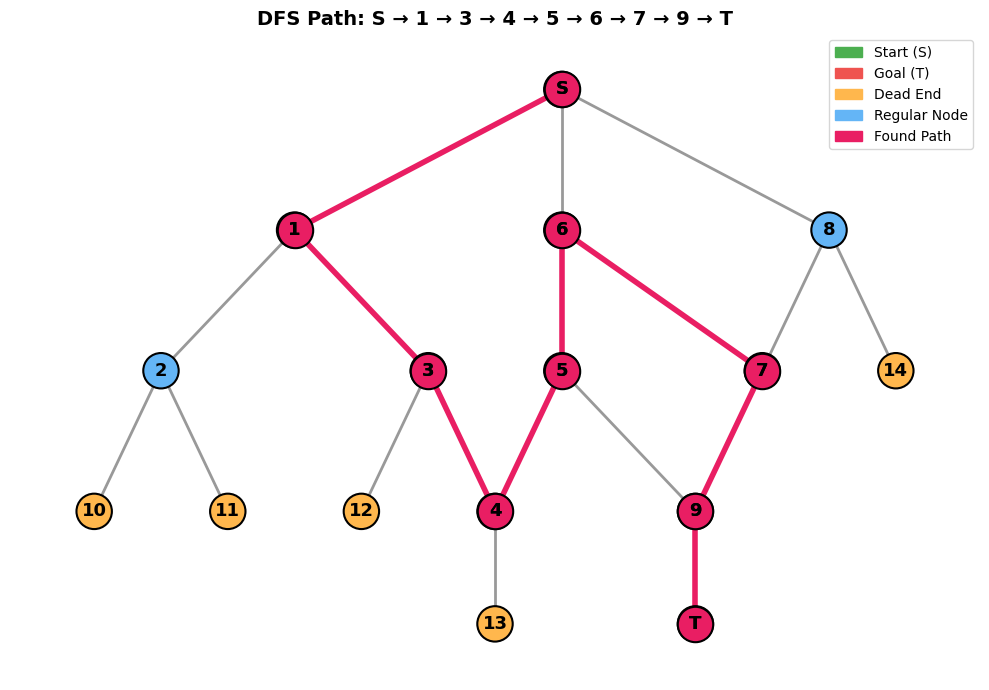

In [14]:
dfs_edges = list(zip(dfs_s_path[:-1], dfs_s_path[1:]))
draw_maze(maze, maze_pos, title=f'DFS Path: {" → ".join(dfs_s_path)}',
            highlight_edges=dfs_edges, highlight_nodes=dfs_s_path)

### 3.7 Comparing BFS and DFS

In [15]:
print("Comparison: BFS vs DFS on the Maze")
print("=" * 50)
print(f"{'':>20} {'BFS':>12} {'DFS (stack)':>12}")
print("-" * 50)
print(f"{'Path length':>20} {len(bfs_path)-1:>12} {len(dfs_s_path)-1:>12}")
print(f"{'Nodes visited':>20} {len(bfs_order):>12} {len(dfs_s_order):>12}")
print(f"{'Path':>20} {' -> '.join(bfs_path):>12}")
print(f"{'':>20} {' -> '.join(dfs_s_path):>12}")
print(f"\nBFS found the shorter path? {len(bfs_path) <= len(dfs_s_path)}")
print(f"DFS found the goal faster (fewer nodes visited)? {len(dfs_s_order) <= len(bfs_order)}")

Comparison: BFS vs DFS on the Maze
                              BFS  DFS (stack)
--------------------------------------------------
         Path length            4            8
       Nodes visited           16           16
                Path S -> 6 -> 5 -> 9 -> T
                     S -> 1 -> 3 -> 4 -> 5 -> 6 -> 7 -> 9 -> T

BFS found the shorter path? True
DFS found the goal faster (fewer nodes visited)? True


## Part 4: Depth-Limited DFS and Iterative Deepening
### 4.2 Depth-Limited DFS Implementation

In [16]:
def depth_limited_dfs(graph, start, goal, limit):
    """
    Depth-Limited DFS using recursion.
    
    Parameters:
    graph: A NetworkX graph
    start: The starting node
    goal: The goal node
    limit: Maximum depth to search
    
    Returns:
    traversal_order: Nodes visited in order
    path: Path to goal, or None
    cutoff_occurred: True if the search was cut off by the depth limit
    """
    visited = set()
    traversal_order = []
    
    def _dldfs(node, path, depth):
        visited.add(node)
        
        traversal_order.append(node)
        
        if node == goal:
            return path, False # Found goal, no cutoff
        
        if depth >= limit:
            return None, True # Reached limit, cutoff occurred
        
        cutoff = False
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                result, child_cutoff = _dldfs(neighbor, path + [neighbor], depth + 1)
                if result is not None:
                    return result, False # Found goal
                if child_cutoff:
                    cutoff = True
        
        return None, cutoff
    
    path, cutoff = _dldfs(start, [start], 0)
    return traversal_order, path, cutoff

### 4.3 Testing Depth-Limited DFS at Various Limits

In [17]:
print(f"Depth-Limited DFS on the Maze (S -> T)")
print(f"{'Limit':>6} {'Found?':>7} {'Path Length':>12} {'Nodes Visited':>14} {'Cutoff?':>8}")
print("-" * 60)
for limit in range(1, 10):
 order,	path, cutoff = depth_limited_dfs(maze, 'S', 'T', limit)
 
 found = path is not None
 plen = len(path) - 1 if found else '-'
 print(f"{limit:>6} {str(found):>7} {str(plen):>12} {len(order):>14} {str(cutoff):>8}")

Depth-Limited DFS on the Maze (S -> T)
 Limit  Found?  Path Length  Nodes Visited  Cutoff?
------------------------------------------------------------
     1   False            -              4     True
     2   False            -              9     True
     3   False            -             13     True
     4    True            4             16    False
     5   False            -             15     True
     6    True            6             14    False
     7   False            -             14     True
     8    True            8             16    False
     9    True            8             16    False


### 4.4 Iterative Deepening Depth-First Search (IDDFS)


IDDFS combines the completeness and optimality of BFS with the space efficiency of DFS. It works by running Depth-Limited DFS repeatedly with __increasing depth limits__ (0, 1, 2, ...) until the goal is found.

__Properties:__
* __Complete:__ Yes.
* __Optimal:__ Yes — like BFS, it finds the shallowest goal.
* __Time complexity:__ $O({b^d})$ — same as BFS, despite the repeated work.
* __Space complexity:__ $O({b.d})$ — same as DFS! This is the key advantage.
  > __Why isn't IDDFS wasteful?__ Although nodes at shallower depths are re-expanded at each iteration, the vast majority of nodes in a tree are at the deepest level. Mathematically, the overhead factor is only , which approaches a constant (e.g., just 2× for ).

### 4.5 IDDFS Implementation

In [19]:
def iddfs(graph, start, goal, max_depth=50):
 """
 Iterative Deepening Depth-First Search.
 
 Repeatedly runs depth-limited DFS with increasing limits until the goal is found.
 
 Returns:
 	traversal_order: Nodes visited in the final (successful) iteration
		path: Path to goal, or None
 	depth_found: The depth limit at which the goal was found
 	total_expanded: Total nodes expanded across ALL iterations
 """
 total_expanded = 0
 
 for limit in range(max_depth + 1):
	 order, path, cutoff = depth_limited_dfs(graph, start, goal, limit)
	 
		total_expanded += len(order)
	 
		if path is not None:
		 return order, path, limit, total_expanded
 
 	if not cutoff:
 		# No cutoff and no goal — the entire graph has been searched
 		break
 
 return [], None, -1, total_expanded

TabError: inconsistent use of tabs and spaces in indentation (<string>, line 18)

In [ ]:
iddfs_order, iddfs_path, iddfs_depth, iddfs_total = iddfs(maze, 'S', 'T')


print(f"IDDFS Result:")
print(f" Goal found at depth limit: {iddfs_depth}")
print(f" Path: {' -> '.join(iddfs_path)}")
print(f" Path length: {len(iddfs_path) - 1} edges")
print(f" Nodes expanded in final iteration: {len(iddfs_order)}")
print(f" Total nodes expanded across all iterations: {iddfs_total}")
print(f"\nComparison:")
print(f" BFS path length: {len(bfs_path) - 1} (nodes expanded: {len(bfs_order)})")
print(f" IDDFS path length: {len(iddfs_path) - 1} (total expanded: {iddfs_total})")
print(f" Same optimal path? {len(iddfs_path) == len(bfs_path)}")


### 4.6 Visualising the IDDFS Iterations

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, limit in enumerate(range(iddfs_depth + 1)):
 ax = axes[i]
 order, path, cutoff = depth_limited_dfs(maze, 'S', 'T', limit)
 
 
 node_colors = []
 for n in maze.nodes():
 	if n == 'S':
 		node_colors.append('#4CAF50')
		elif n == 'T' and path is not None:
	  node_colors.append('#EF5350')
 	elif n in order:
 		node_colors.append('#CE93D8') # Purple — visited
 	elif maze.degree(n) == 1:
 		node_colors.append('#FFB74D')
 	else:
 		node_colors.append('#E0E0E0') # Grey — not visited
 
 nx.draw(maze, maze_pos, ax=ax, with_labels=True, 
		 						node_color=node_colors, node_size=450,
 								font_size=10, font_weight='bold',
									edge_color='#CCCCCC', width=1.5,
									edgecolors='black', linewidths=1)
 
 if path:
	 path_edges = list(zip(path[:-1], path[1:]))
	 nx.draw_networkx_edges(maze, maze_pos, edgelist=path_edges, edge_color='#E91E63', width=3, ax=ax)
 
status = f"FOUND! Path: {' → '.join(path)}" if path else f"Not found (cutoff={cutoff})"
ax.set_title(f'Depth Limit = {limit}\n{status}', fontsize=11)

# Hide unused subplot
for j in range(i + 1, len(axes)):
 axes[j].set_visible(False)
plt.suptitle('IDDFS: Iterations at Each Depth Limit\n(Purple = visited nodes)',
 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Part 5: Algorithm Comparison Summary

In [ ]:
# Comprehensive comparison
print("Algorithm Comparison on the Maze (S -> T)")
print("=" * 75)
print(f"{'Algorithm':<25} {'Path Length':>12} {'Nodes Visited':>14} {'Optimal?':>10} {'Complete?':>10}")
print("-" * 75)

algorithms = [
 ("BFS", bfs_path, bfs_order),
 ("DFS (stack)", dfs_s_path, dfs_s_order),
 ("DFS (recursive)", dfs_r_path, dfs_r_order),
 ("IDDFS", iddfs_path, iddfs_order)
]

for name, path, order in algorithms:
 plen = len(path) - 1 if path else '-'
 optimal = "Yes" if path and len(path) == len(bfs_path) else "No"
 print(f"{name:<25} {str(plen):>12} {len(order):>14} {optimal:>10} {'Yes':>10}")
 
print(f"\nIDDFS total expanded across all iterations: {iddfs_total}")


## Part 6: The 8-Puzzle — State-Space Search
### 6.3 Representing and Visualising States

In [ ]:
def display_state(state, title=None):
 """Display an 8-puzzle state as a grid."""
 if title:
  print(title)
 for i in range(3):
  row = state[i*3:(i+1)*3]
  print(" | ".join(str(x) if x != 0 else " " for x in row))
  if i < 2:
   print("---------")
   
 print()
 
def plot_state(state, ax, title=""):
 """Plot an 8-puzzle state as a coloured grid."""
 ax.set_xlim(-0.5, 2.5)
 ax.set_ylim(-0.5, 2.5)
 ax.set_aspect('equal')
 ax.invert_yaxis()
 ax.set_title(title, fontsize=10, fontweight='bold')
 ax.set_xticks([])
 ax.set_yticks([])
 
 for i in range(3):
  for j in range(3):
   val = state[i * 3 + j]
   color = '#EEEEEE' if val == 0 else '#64B5F6'
   rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, facecolor=color, edgecolor='black', linewidth=2)
   
   ax.add_patch(rect)
   if val != 0:
    ax.text(j, i, str(val), ha='center', va='center',
            fontsize=18, fontweight='bold')
    
# Define states
goal_state = (1, 2, 3, 4, 5, 6, 7, 8, 0)
start_state = (1, 2, 3, 4, 0, 5, 7, 8, 6) # 3 moves from goal

display_state(start_state, "Start State:")
display_state(goal_state, "Goal State:")

### 6.4 Generating Successor States

In [ ]:
def get_successors(state):
 """
 Generate all states reachable from the given 8-puzzle state by one move.
 
 The blank (0) can swap with any orthogonally adjacent tile.
 
 Parameters:
 state: A tuple of 9 integers representing the puzzle
 
 Returns:
 List of (new_state, move_description) tuples
 """
 state = list(state)
 blank = state.index(0)
 row, col = blank // 3, blank % 3
 
 successors = []
 moves = [(-1, 0, "up"), (1, 0, "down"), (0, -1, "left"), (0, 1, "right")]
 
 for dr, dc, direction in moves:
  nr, nc = row + dr, col + dc
  if 0 <= nr < 3 and 0 <= nc < 3:
   new_state = state[:]
   swap_pos = nr * 3 + nc
   new_state[blank], new_state[swap_pos] = new_state[swap_pos], new_state[blank]
   successors.append((tuple(new_state), f"slide {state[swap_pos]} {direction}"))
 
 return successors

# Show successors of the start state
print("Successors of the start state:")
display_state(start_state, "Current state:")
for succ, move in get_successors(start_state):
 display_state(succ, f"After: {move}")

### 6.5 BFS on the 8-Puzzle

In [ ]:
def bfs_8puzzle(start, goal):
 """
 BFS on the 8-puzzle state space (implicit graph).
 
 Returns:
 path: List of states from start to goal
 expanded: Number of nodes expanded
 """
 if start == goal:
  return [start], 0
 
 visited = {start}
 
 
 queue = deque([(start, [start])])

 
 expanded = 0
 
 while queue:
  state, path = queue.popleft()
  expanded += 1
 
  for successor, move in get_successors(state):
   if successor == goal:
    return path + [successor], expanded
   if successor not in visited:
    visited.add(successor)
    queue.append((successor, path + [successor]))
 
 return None, expanded

# Solve from the start state
path_8p, expanded_8p = bfs_8puzzle(start_state, goal_state)

print(f"BFS found a solution in {len(path_8p) - 1} moves, expanding {expanded_8p} nodes.")
print(f"\nSolution sequence:")
for i, state in enumerate(path_8p):
 display_state(state, f"Step {i}:")


### 6.6 Visualising the 8-Puzzle Solution

In [ ]:
n_steps = len(path_8p)
fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3.5))
if n_steps == 1:
 axes = [axes]
 
for i, (state, ax) in enumerate(zip(path_8p, axes)):
 plot_state(state, ax, title=f"Step {i}")
plt.suptitle(f'8-Puzzle BFS Solution ({n_steps - 1} moves, {expanded_8p} nodes expanded)',
 fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.7 BFS vs DFS on the 8-Puzzle

In [ ]:
# A harder start state (6 moves from goal)
hard_start = (4, 1, 3, 7, 2, 5, 0, 8, 6)
display_state(hard_start, "Harder start state:")
# BFS
# TODO: run BFS and get the resulting path and expanded nodes count
print(f"BFS: {len(bfs_path_hard)-1} moves, {bfs_exp_hard} nodes expanded")
# DFS with depth limit
def dfs_8puzzle(start, goal, max_depth=15):
 """DFS with depth limit for the 8-puzzle."""
 visited = set()
 # TODO: Create the stack here (see Cell 3.5)
 
 expanded = 0
 
 while stack:
 # TODO: pop and get 'state' and 'path' from 'stack' (see Cell 3.5)
 
 if state in visited:
 continue
 # TODO: add 'state' to 'visited'

expanded += 1
 
 if state == goal:
 return path, expanded
 
 if len(path) - 1 < max_depth:
 for successor, move in get_successors(state):
 if successor not in visited:
 stack.append((successor, path + [successor]))
 
 return None, expanded
# TODO: run BFS and get the resulting path and expanded nodes count
dfs_found = dfs_path_hard is not None
print(f"DFS (limit=15): {len(dfs_path_hard)-1 if dfs_found else 'NOT FOUND'} moves, "
 f"{dfs_exp_hard} nodes expanded")
# IDDFS
def iddfs_8puzzle(start, goal, max_depth=20):
 """IDDFS for the 8-puzzle."""
 total_expanded = 0
 for limit in range(max_depth + 1):
  visited = set()
  # TODO: Create the stack here (see Cell 6.7)
 
  expanded = 0
  found = None
  
  while stack:
   # TODO: pop and get 'state' and 'path' from 'stack' (see Cell 6.7)
 
   if state in visited:
    continue
   # TODO: add 'state' to 'visited'
 
   expanded += 1
   if state == goal:
    found = path
    break
   if len(path) - 1 < limit:
    for successor, move in get_successors(state):
     if successor not in visited:
      stack.append((successor, path + [successor]))
  total_expanded += expanded
  if found:
   return found, total_expanded, limit
 return None, total_expanded, -1
# TODO: run IDDFS and get the resulting path and expanded nodes count
print(f"IDDFS: {len(iddfs_path_hard)-1 if iddfs_path_hard else 'NOT FOUND'} moves, "
 f"{iddfs_exp_hard} total nodes expanded (found at depth {iddfs_d_hard})")
print(f"\nComparison:")
print(f" BFS is optimal ({len(bfs_path_hard)-1} moves) but expanded {bfs_exp_hard} nodes")
if dfs_found:
 print(f" DFS found a {len(dfs_path_hard)-1}-move solution but expanded {dfs_exp_hard} nodes")
else:
 print(f" DFS failed to find a solution within the depth limit (expanded {dfs_exp_hard} nodes)")
print(f" IDDFS is optimal ({len(iddfs_path_hard)-1} moves) and expanded {iddfs_exp_hard} total nodes")
